# <center>MDSA D213 Advanced Data Analytics</center> 

## <center>Task 1  Time Series Modeling Rev.I</center>

## <center>Justin Jordan</center>

## <center>7/29/2026</center>

## <center>WGU</center>



## Part I: Research Question

### A.   Describe the purpose of this data analysis by doing the following:

1.  Summarize one research question that is relevant to a real-world organizational situation captured in the selected data set and that you will answer using time series modeling techniques.

    - Can we predict future revenue using time series and an ARIMA model?      

2.  Define the objectives or goals of the data analysis. Ensure your objectives or goals are reasonable within the scope of the scenario and are represented in the available data.

    - The goal of this analysis will be to produce a forecast of the company's future revenue using an ARIMA model.       

## Part II: Method Justification

### B.   Summarize the assumptions of a time series model including stationarity and autocorrelated data.

- Autocorrelated
    - Autocorrelated measures the linear relationship between lagged values of a time series(2.8 autocorrelation | forecasting: Principles and practice (3rd Ed)).

- Stationarity
    - Stationary refers to the idea that the mean, variance, and autocorrelation structure are constant over time.  

- Seasonality 
    - Seasonality exhibits a trend that repeats with respect to timing, direction and magnitude(2020).  

            
        
        

## Part III: Data Preparation

### C.  Summarize the data cleaning process by doing the following:

1.  Provide a line graph visualizing the realization of the time series.
 


In [103]:
# import libraries and df load
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import scipy.stats as stats
from scipy.signal import periodogram
import sklearn
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import matplotlib.gridspec as gridspec
from datetime import datetime
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# code for data frame
df = pd.read_csv("C:/users/jjord/Documents/WGU/D213/d213_pa1/teleco_time_series .csv")

# Profile of Data Frame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Day      731 non-null    int64  
 1   Revenue  731 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 11.6 KB


In [104]:
df.head()


,Day,Revenue
0,1,0.000000
1,2,0.000793
2,3,0.825542
3,4,0.320332
4,5,1.082554


In [105]:
df.isnull().sum()

Day        0
Revenue    0
dtype: int64

In [106]:
#c2 formatting
df["Day"] = pd.date_range(start= datetime(2020,1,1), periods = len(df), freq= 'D')
df.set_index("Day", inplace=True)
df.head()

,Revenue
Day,
2020-01-01,0.000000
2020-01-02,0.000793
2020-01-03,0.825542
2020-01-04,0.320332
2020-01-05,1.082554


### C1 Visualization

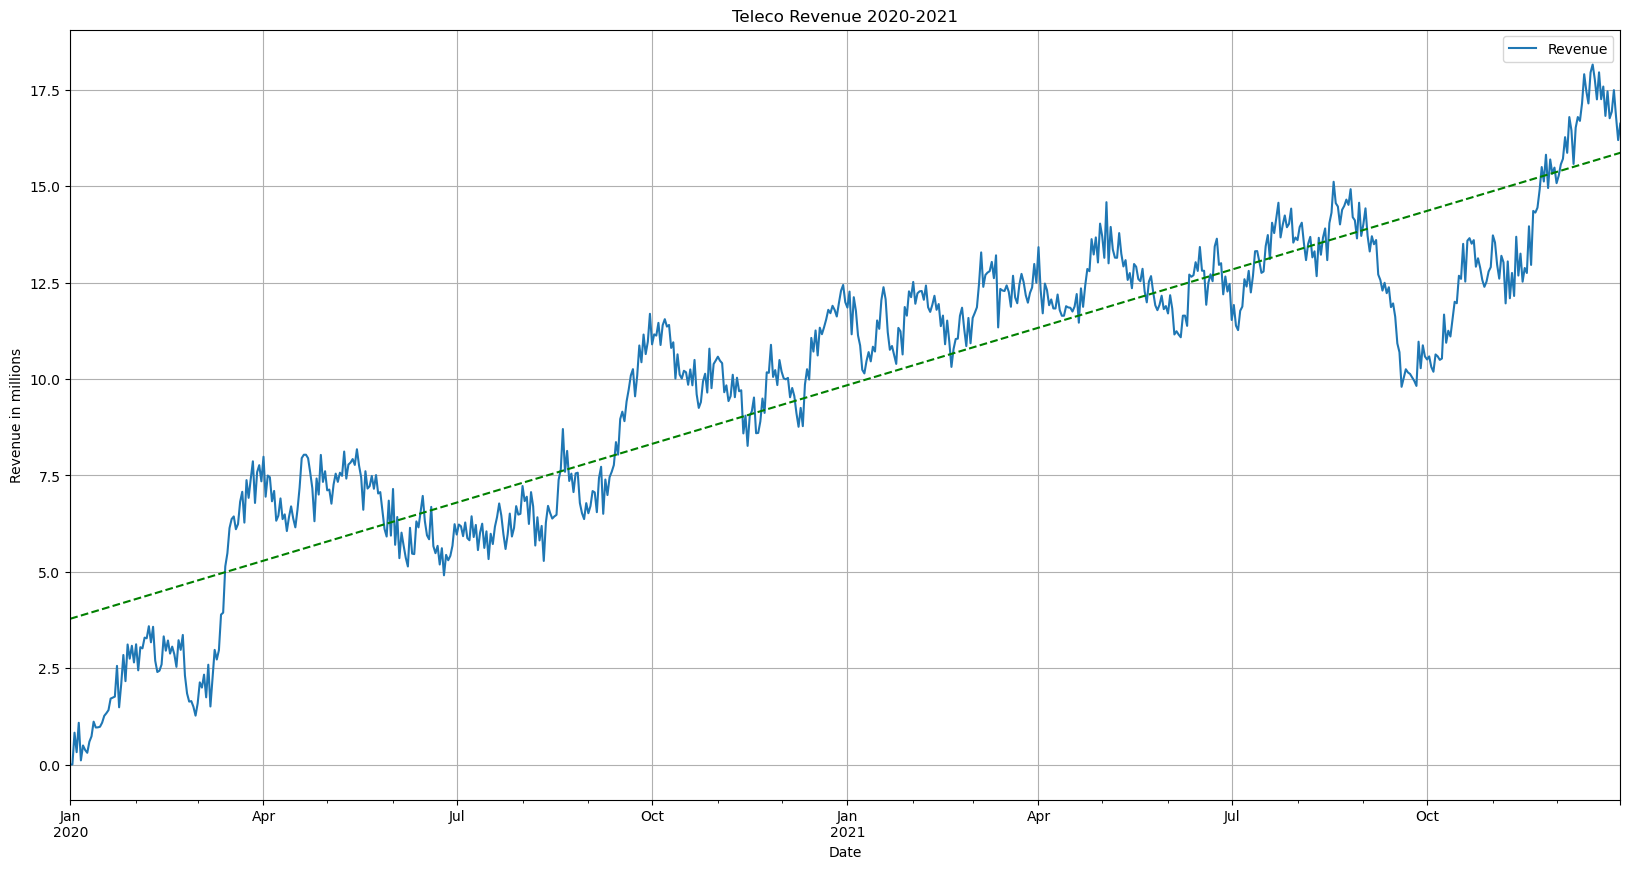

In [107]:
#code for C1
df.plot(grid=True, figsize=(20,10))
plt.title("Teleco Revenue 2020-2021")
plt.xlabel("Date")
plt.ylabel("Revenue in millions")

x = mdates.date2num(df.index)
y = df["Revenue"]
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(x, p(x), "g--")

plt.legend()
plt.show()

In [108]:
#export
df.to_csv("clean_teleco.csv")



2.  Describe the time step formatting of the realization, including any gaps in measurement and the length of the sequence.

   - The time step formatting of the realization is a date range begining 1-1-2020 with a daily frequency that has been assigned to the "Day" column.  There are no gaps in the measurement and the legnth of the sequence is 731 days.    


3. Evaluate the stationarity of the time series.
    
   - The graph from C1 shows an upward trend which may indicate a lack of stationarity.  To check for this, we will use an Augmented Dickey-Fuller test to fully evaluate for stationarity.   
    


In [109]:
#c3 code
test_adf = adfuller(df)
def check_stationarity(df):
    result = adfuller(df)
    print('ADF Statistic: ', test_adf[0])
    print('P-value: ', test_adf[1])
    print('Critical Values: ', test_adf[4])

check_stationarity(df['Revenue'])


ADF Statistic:  -1.924612157310184
P-value:  0.3205728150793963
Critical Values:  {'1%': np.float64(-3.4393520240470554), '5%': np.float64(-2.8655128165959236), '10%': np.float64(-2.5688855736949163)}


#### C3 cont.

- After performing the ADF test, the data was no stationary.  The Revenue column was passed thru the function and returned a P-value of .32, which is greater than the .05 valued to reject a null hypothesis.  Since the data is not stationary, we will need to diff the data to make it stationary.  Below is the code used to diff the data as well as an additional ADF test on the diff'd data.


In [110]:
#code for diff'd data and additional ADF
stationary_df = df.diff().dropna()

result = adfuller(stationary_df["Revenue"])
print("Diff'd ADF Statistics: ", result[0])
print("P-Value: ", result[1])
print("Critical Values: ", result[4])

Diff'd ADF Statistics:  -44.87452719387599
P-Value:  0.0
Critical Values:  {'1%': np.float64(-3.4393520240470554), '5%': np.float64(-2.8655128165959236), '10%': np.float64(-2.5688855736949163)}


In [111]:
#set up Stationairty test
def test_stationarity(timeseries):
    #Determing rolling statistics
    rolmean = timeseries.rolling(window=30).mean()
    rolstd = timeseries.rolling(window=30).std()

    #Plot rolling statistics:
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)

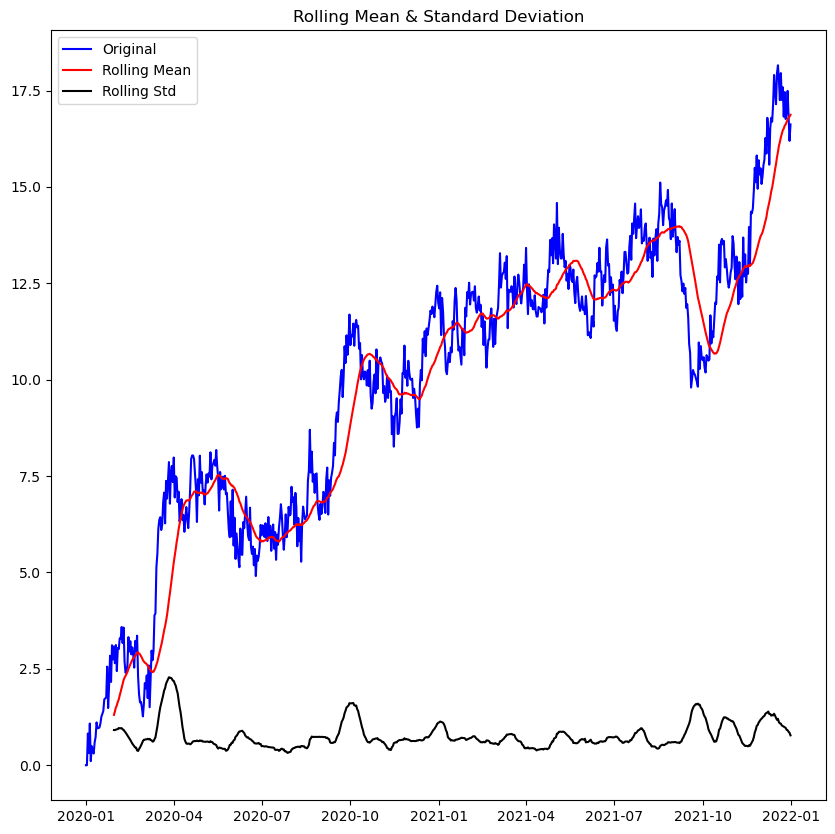

In [112]:
test_stationarity(df['Revenue'])

In [113]:
#test, train split
# 80/20 split 
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size-1:]



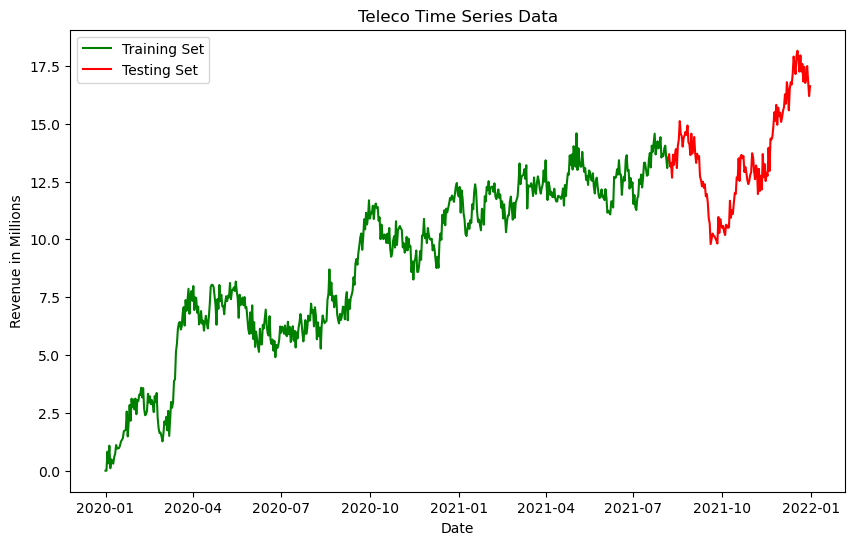

In [115]:
#visual of split
plt.figure(figsize=(10,6))
plt.plot(train['Revenue'], label = 'Training Set', color='green')
plt.plot(test['Revenue'], label= 'Testing Set', color='red')
plt.title('Teleco Time Series Data')
plt.xlabel('Date')
plt.ylabel('Revenue in Millions')
plt.legend()
plt.show()

In [116]:

#export
train.to_csv("train.csv")
test.to_csv("test.csv")

In [117]:
#diff'd to csv(not sure if needed or not )
stationary_df.to_csv("clean_teleco_diffd.csv")


4. Explain the steps you used to prepare the data for analysis, including the training and test set split.

- Steps to prepare the data, including training and test split from code above are as follows:
    - Checked for Null values
    - Changed Day column to reflect actual dates
    - Reset index for new values in Day column
    - Performed ADF test
    - Diff'd data for stationarity and reperformed ADF test
    - Split data into test and train sets with 80/20 split

5. Provide a copy of the cleaned data set. 

- Copies of cleaned data(before diff'd), test and train will be attached to submission in csv format.



## Part IV: Model Identification and Analysis

### D.  Analyze the time series data set by doing the following:
1.   Report the annotated findings with visualizations of your data analysis, including the following elements:

- the presence or lack of a seasonal component

- trends

- the autocorrelation function

- the spectral density

- the decomposed time series

- confirmation of the lack of trends in the residuals of the decomposed series


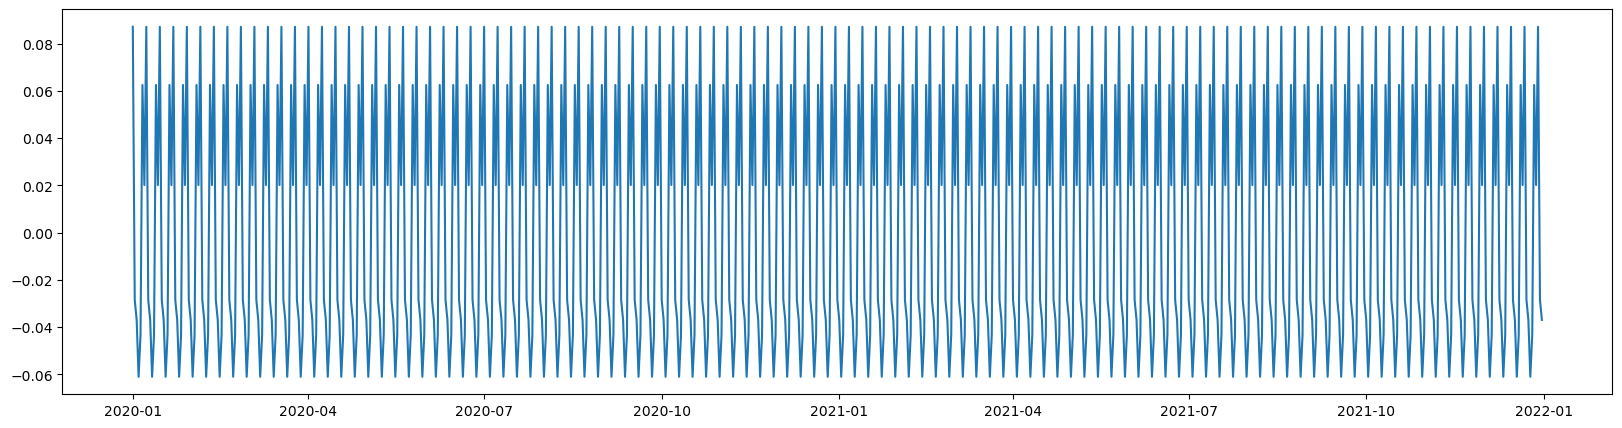

In [118]:
#d1 code
# seasonality

decomposition = seasonal_decompose(df)
plt.figure(figsize=[20,5])
plt.plot(decomposition.seasonal)
plt.show()


### D1. continued

### Seasonality
- The seasonal plot above shows a seasonal component to the data.  It does show a repeating pattern.


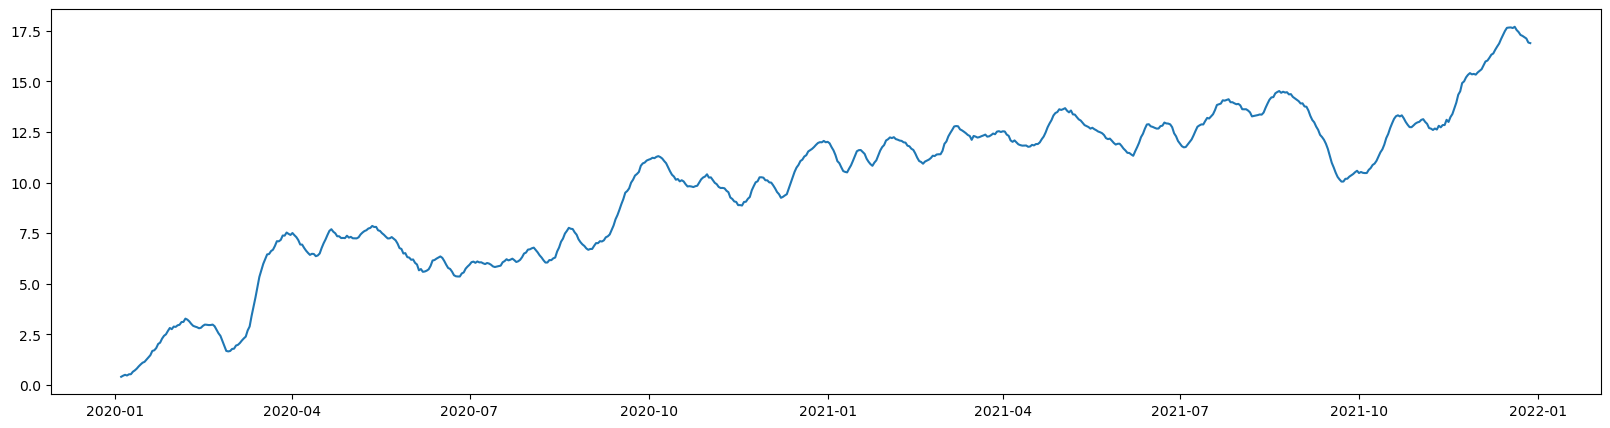

In [119]:
#trend
plt.figure(figsize=[20,5])
plt.plot(decomposition.trend)


### Trends
- The trend plot above shows an upward trend in the data.  It starts at 0 on 2020-01 and trends upward to 2022-01.


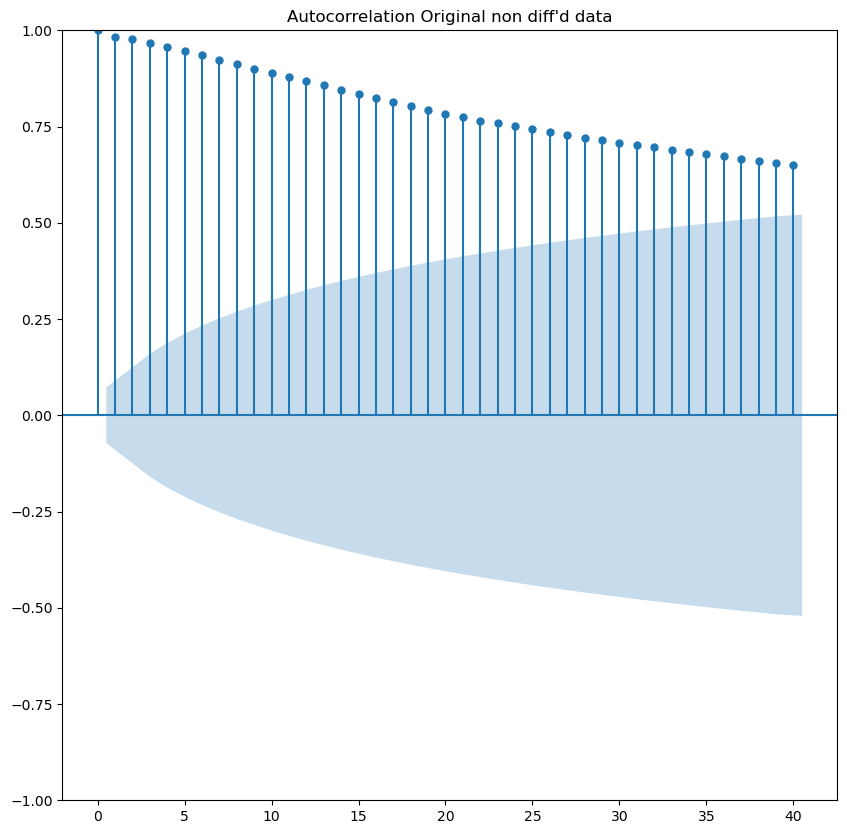

In [120]:
#d1 autocorrelation

#autocorrelation original non diff'd data
plot_acf(df, lags=40)
plt.title("Autocorrelation Original non diff'd data")
plt.show()


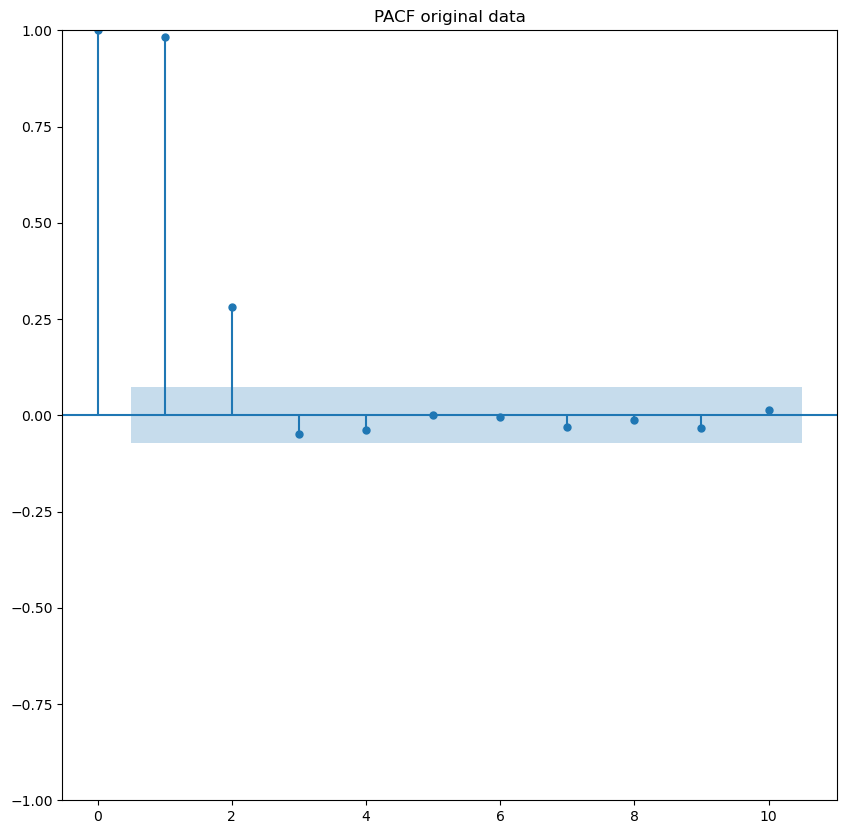

In [121]:

#pacf original data
plot_pacf(df, lags=10)
plt.title("PACF original data")
plt.show()


### D1. continued

### Autocorrelation
- The autocorrelation of the original data shows it is not stationary.  You can see the trend line in the plot and that the coefficients do not return to zero, which is expected for that data since it is not stationary.  By looking at both the ACF and PACF above, we can take an educated guess at what the order of our model may be.  With the ACF indicating non stationary data, and the PACF cutting off at lag 2, an ARIMA model of (2,1,0) may be a good fit fot the data.    



(array([6.97387711e+03, 3.91439441e+03, 5.47611144e+01, 1.10791953e+01,
        4.25439684e+00, 8.90767103e+00, 9.32436541e+00, 5.07699490e+00,
        4.50820186e+00, 1.97142105e+00, 3.17930644e+00, 2.05465010e+00,
        1.27856111e-01, 9.12357670e-01, 1.58928494e+00, 1.82600308e+00,
        1.37345831e+00, 1.08602805e+00, 3.71664573e-01, 4.01447712e-01,
        6.67019362e-01, 4.28134847e-01, 1.08303874e+00, 5.05461139e-01,
        1.49612021e-01, 2.01156666e-01, 2.01929017e-01, 3.62482513e-02,
        4.74386760e-01, 5.46619399e-01, 2.44460915e-01, 4.75225583e-01,
        2.85007556e-01, 7.59631735e-02, 2.43183009e-01, 7.19503505e-02,
        3.60475608e-01, 2.18971480e-01, 1.23421972e-01, 1.69234109e-01,
        1.69371921e-01, 1.14748035e-01, 2.14144408e-01, 2.82736486e-01,
        3.17059554e-02, 1.62458482e-02, 3.98324693e-02, 6.38895068e-02,
        4.57061837e-02, 6.54718394e-02, 1.72598760e-01, 1.32802101e-01,
        6.74716970e-02, 1.61089989e-02, 1.42266347e-01, 1.236409

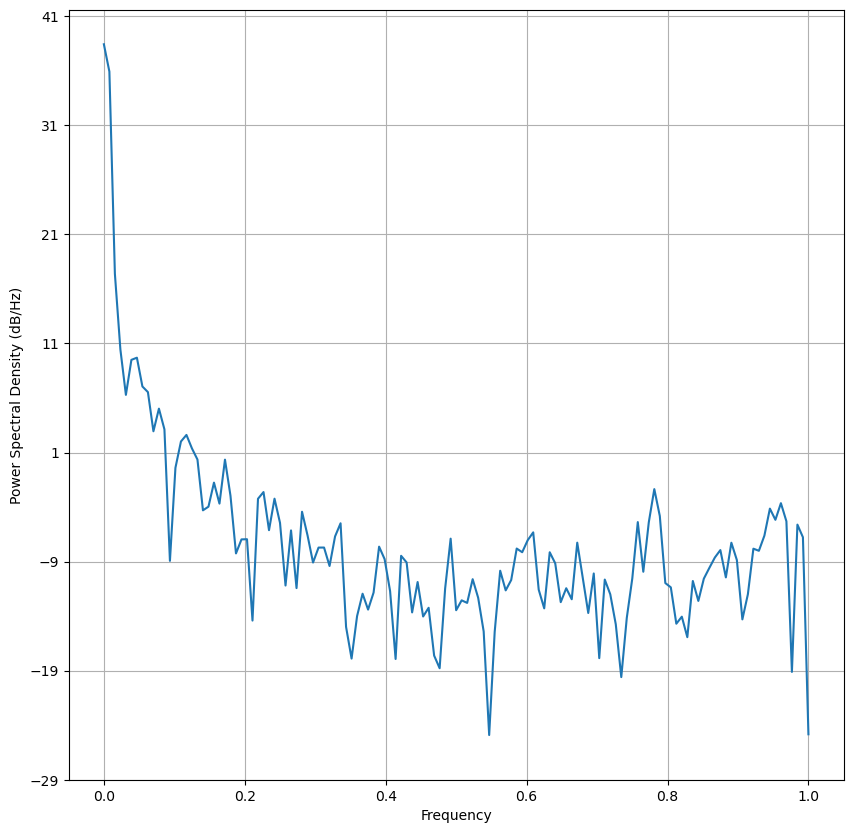

In [122]:
#d1 spectral density
##plt.psd(df.Revenue)
##plt.show()
plt.psd(df['Revenue'])

### D1. continued

### Spectral Density
- The power spectral density plot above shows the time and variance between the previous and current time periods or covariance.  It shows a decent amount of overall variability.   

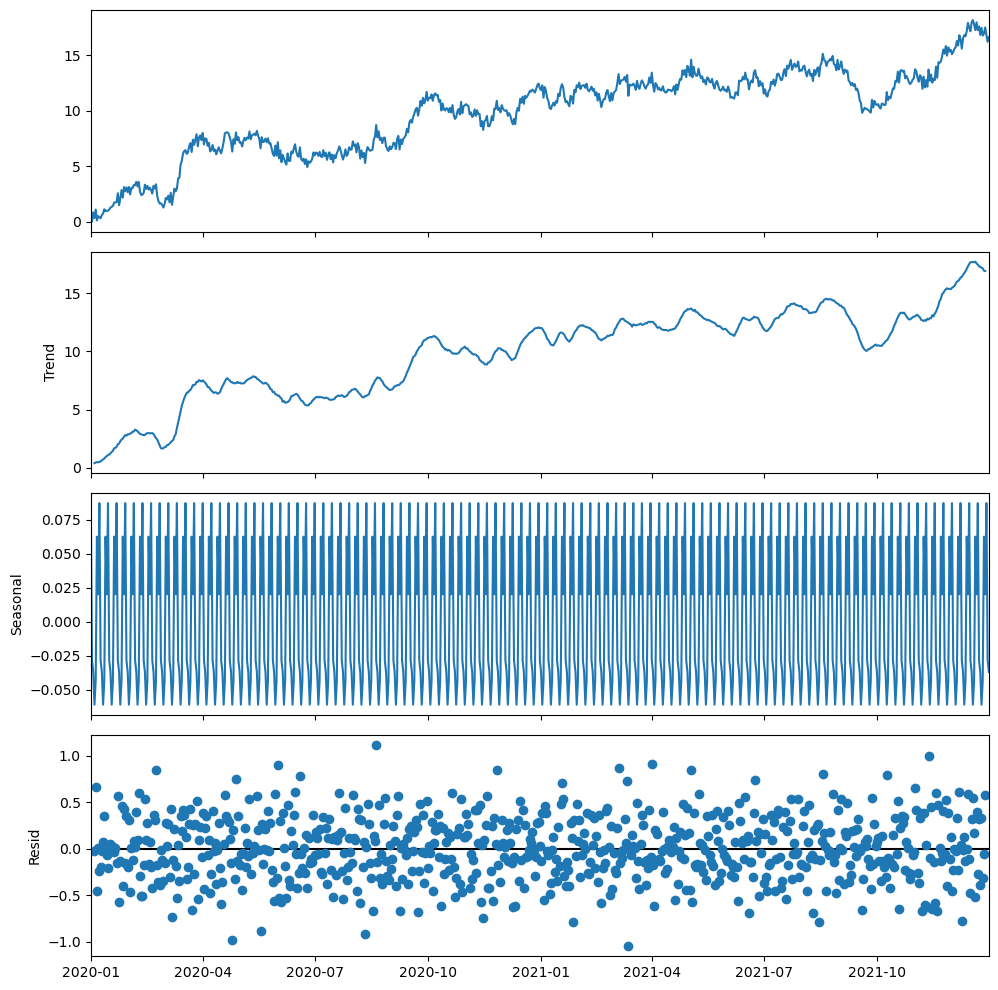

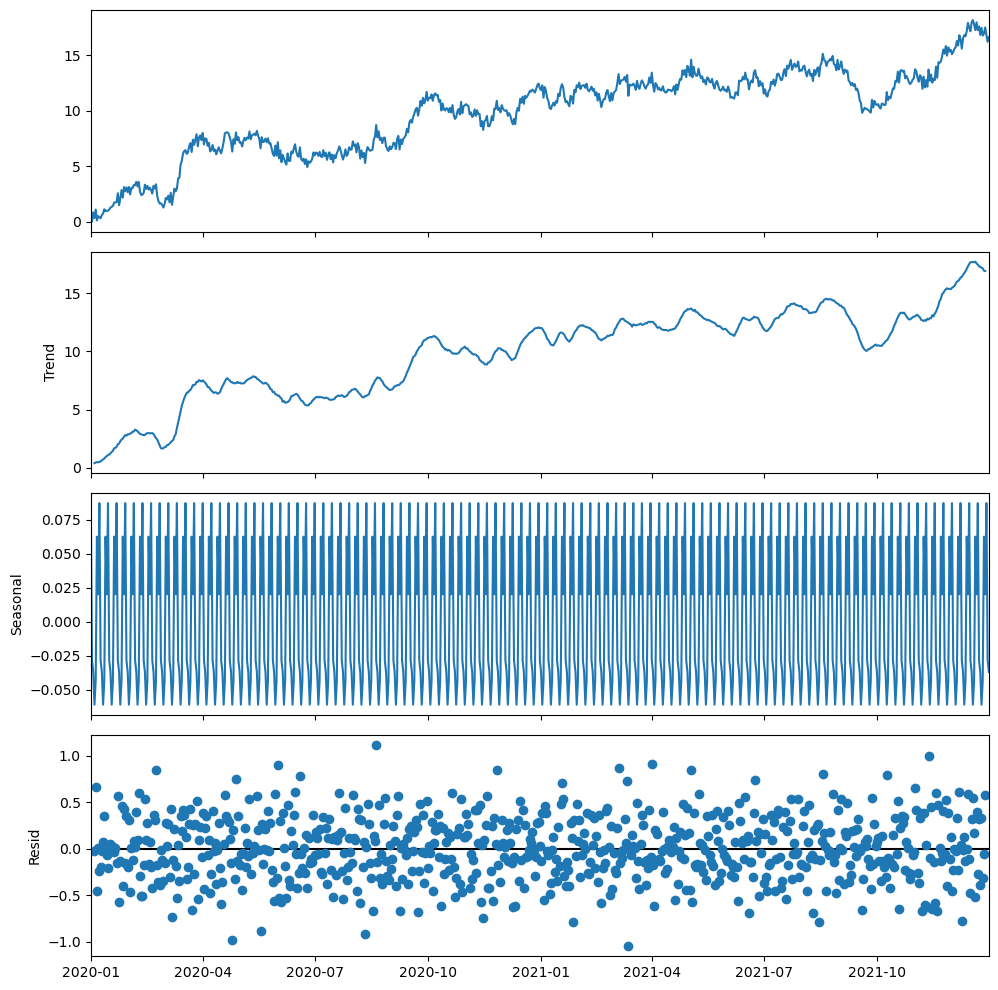

In [123]:
decomposition.plot()

### D1. continued

### Decomposed time series
- The above plot is a full decomposed time series.  It shows an upward trend within that data.  It also shows the seasonality of the data, which does show a repeating pattern in the data.  The residuals show a good amount of variance within the data as it looks to be randomly spaced.   


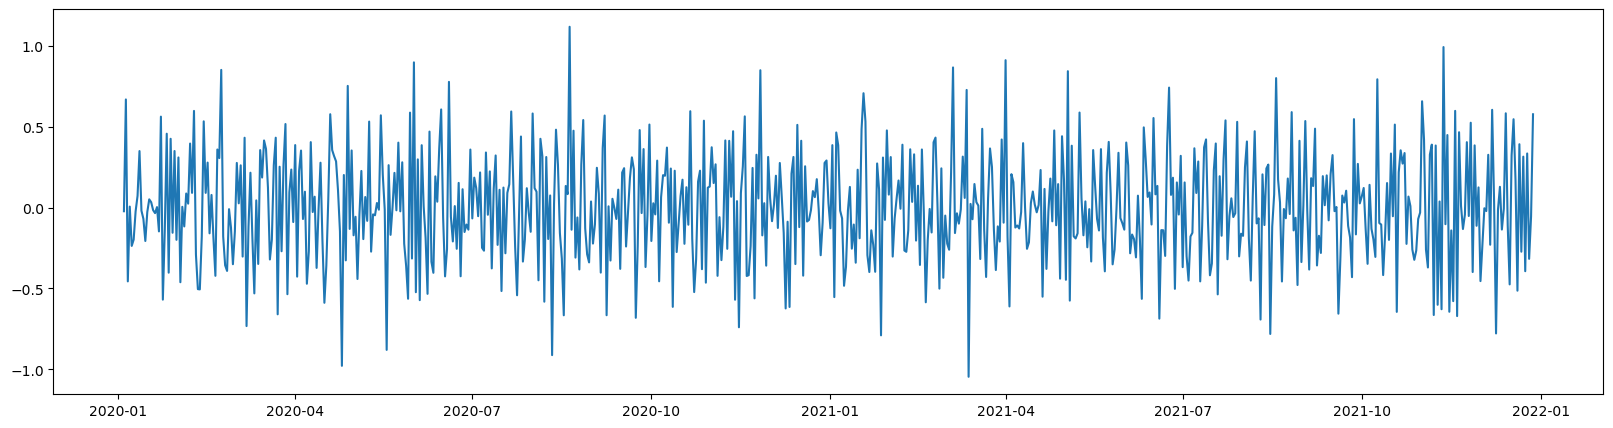

In [124]:
# residuals
plt.figure(figsize=[20,5])
plt.plot(decomposition.resid)


### Confirmation of the lack of trends in Residuals
- As shown above, the residuals do not appear to show any trend.  This confirms our findings from the decomposed time series for the residuals.  

### D1. continued

### Trasformation of original data by differencing to attain stationarity and remove trend.

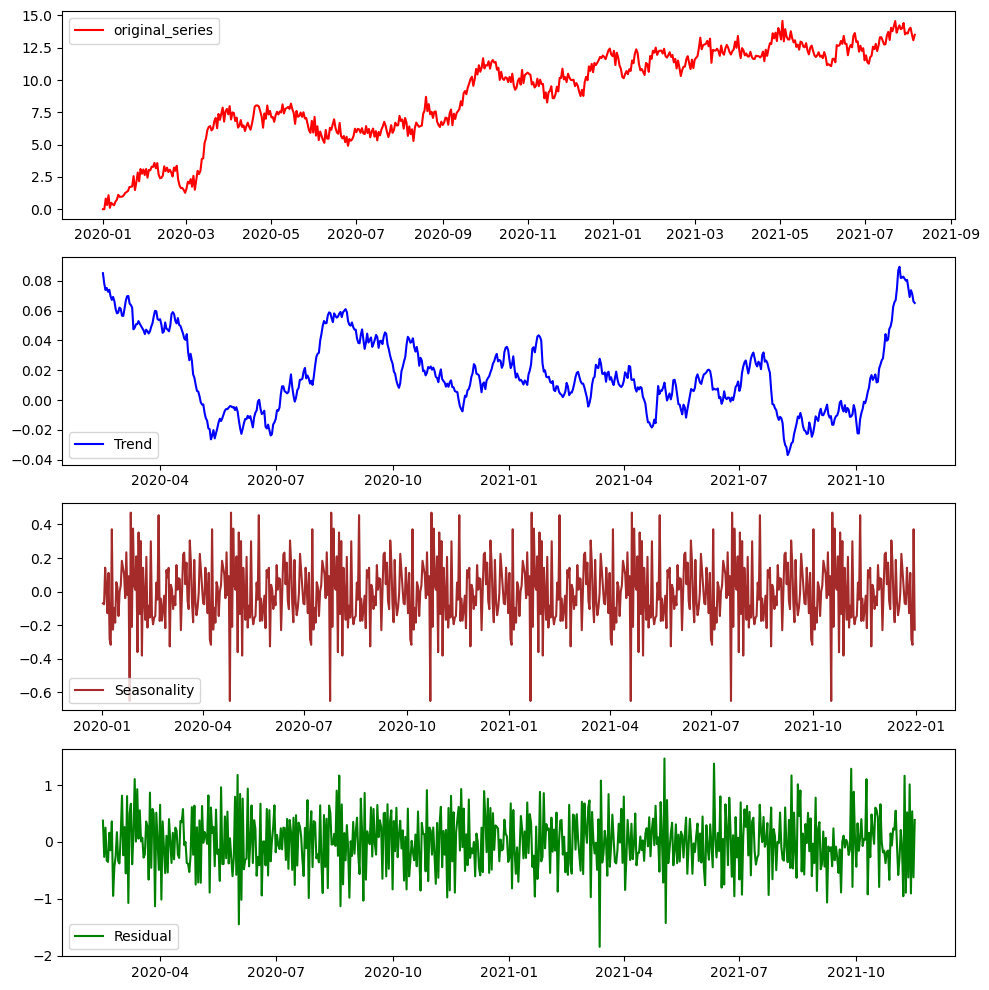

In [125]:
#decompose and plot again after differencing
decomposition=seasonal_decompose(stationary_df, model='additive', period=90)
trend=decomposition.trend
seasonal=decomposition.seasonal
residual=decomposition.resid
plt.subplot(411)
plt.plot(train['Revenue'],color='red', label='original_series')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(trend,color='blue', label='Trend')
plt.legend(loc='best')
plt.tight_layout()
plt.subplot(414)
plt.plot(residual,color='green', label='Residual')
plt.legend(loc='best')
plt.tight_layout()
plt.subplot(413)
plt.plot(seasonal,color='brown', label='Seasonality')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

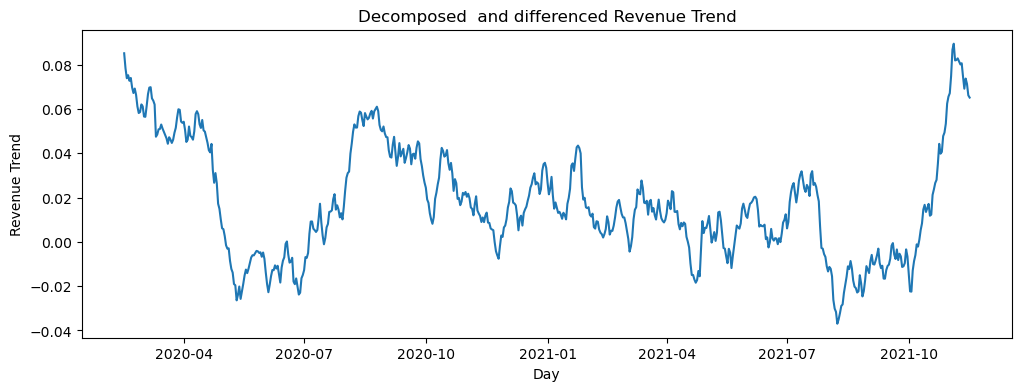

In [126]:
# Plot the trend component only again to confirm trend is eliminated
plt.figure(figsize=(12, 4))
plt.plot(trend, color='tab:blue')
plt.xlabel('Day')
plt.ylabel('Revenue Trend')
plt.title('Decomposed  and differenced Revenue Trend')
plt.show()

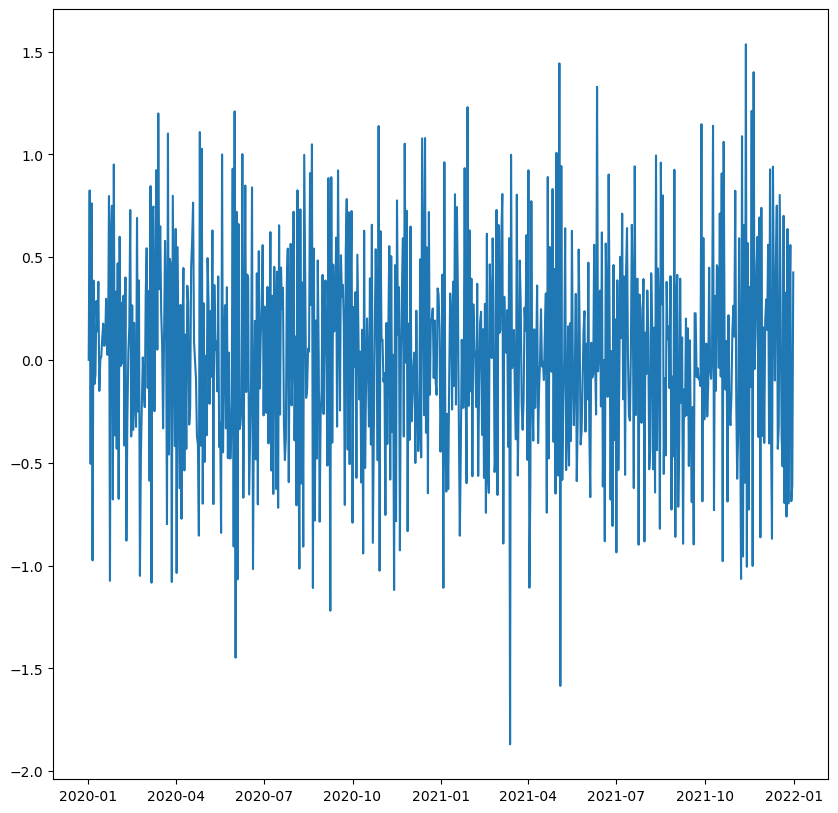

In [127]:
#re-plot of residuals
plt.plot(stationary_df)
plt.show()

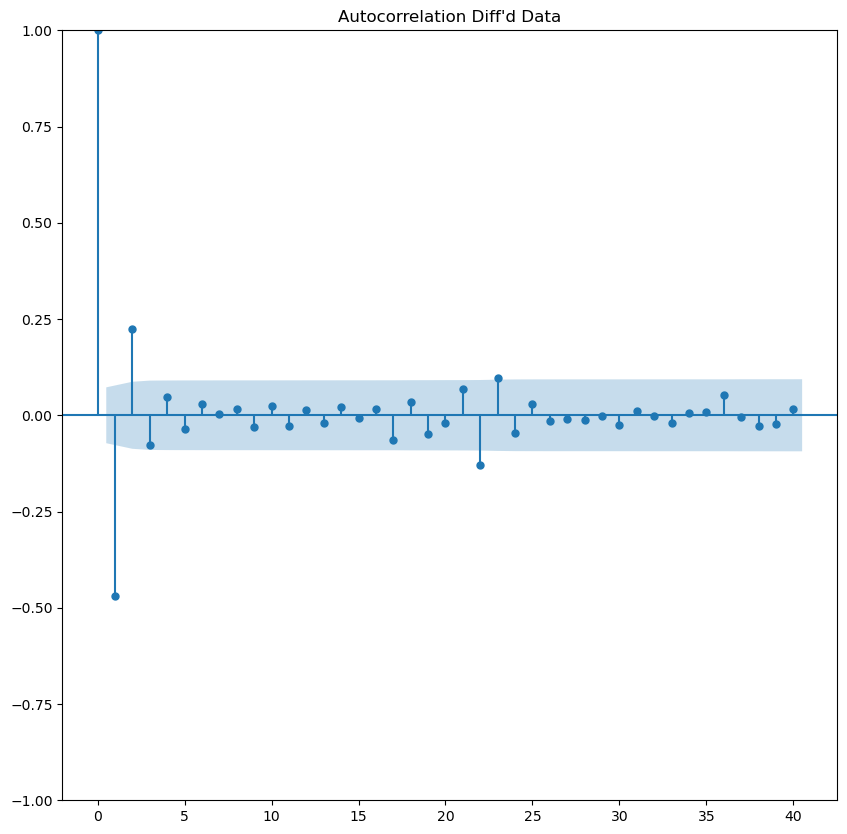

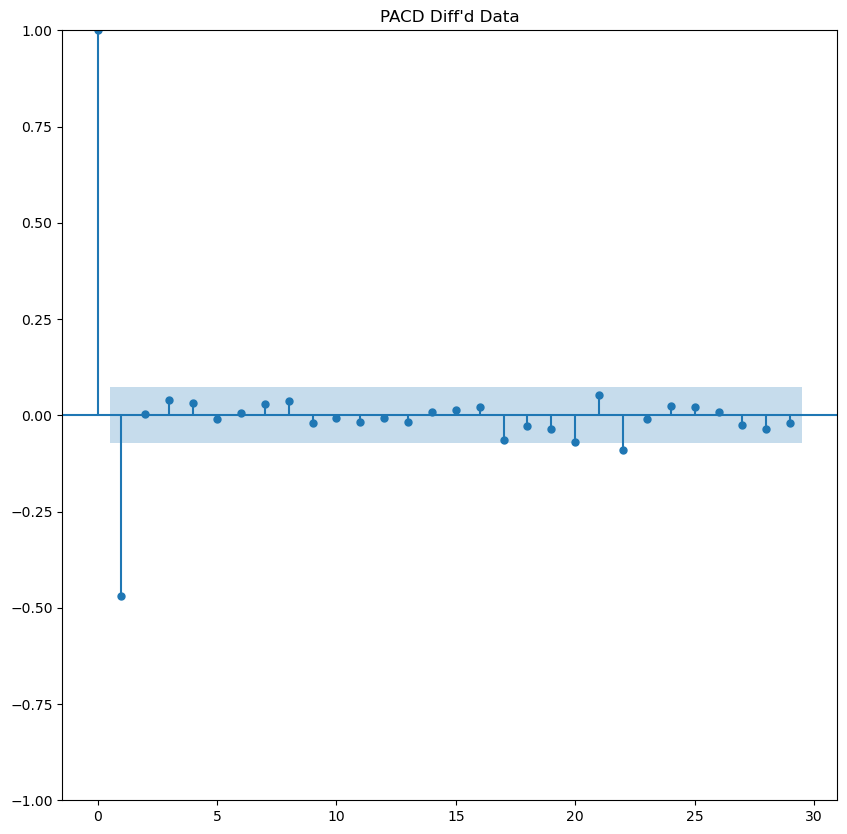

In [128]:
# acf and pacf for diff'd data
plot_acf(stationary_df, lags=40)
plt.title("Autocorrelation Diff'd Data")
plt.show()

plot_pacf(stationary_df)
plt.title("PACD Diff'd Data")
plt.show()

### D1. continued

- From the plots above, we can see that the data is now stationary after differencing.  The coefficients quickly center around zero.  

In [129]:
#ADF for differenced data 
adft_diff = adfuller(stationary_df, autolag='AIC')
print("1. ADF c-value : ",adft_diff[0])
print("2. P-Value : ", adft_diff[1])
print("3. Num Of Lags : ", adft_diff[2])
print("4. Num Of Observations Used :", adft_diff[3])
print("5. Critical Values :")
for key, val in adft_diff[4].items():
    print("\t",key, ": ", val)

1. ADF c-value :  -44.87452719387599
2. P-Value :  0.0
3. Num Of Lags :  0
4. Num Of Observations Used : 729
5. Critical Values :
	 1% :  -3.4393520240470554
	 5% :  -2.8655128165959236
	 10% :  -2.5688855736949163


- ADF test shows Pvalue is zero which also confirms data is stationary.

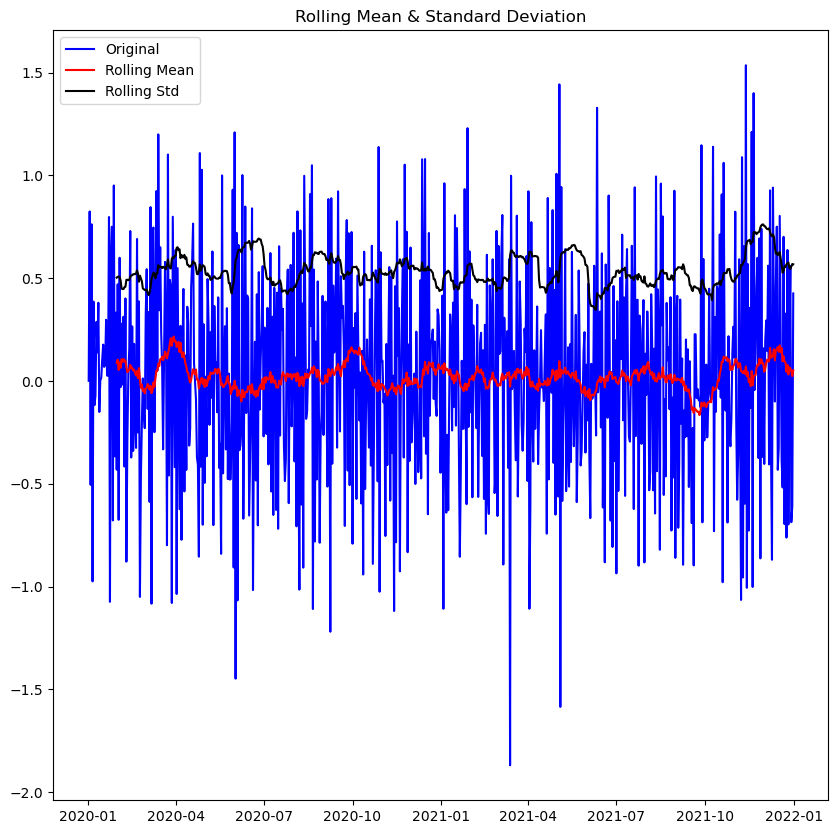

In [130]:
#visualization of confirming stationary data
df_diff=pd.DataFrame(stationary_df)
test_stationarity(df_diff)

- Mean is constand and pretty much at zero.

### D2.

2.  Identify an autoregressive integrated moving average (ARIMA) model that accounts for the observed trend and seasonality of the time series data.
 


In [146]:
stepwise_fit=auto_arima(df['Revenue'], trace=True, suppress_warnings=True)
stepwise_fit.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=987.305, Time=0.37 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1162.819, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=983.122, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1019.369, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1162.139, Time=0.02 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=985.104, Time=0.08 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=985.106, Time=0.04 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=986.045, Time=0.31 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=984.710, Time=0.03 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0] intercept
Total fit time: 1.024 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  731
Model:               SARIMAX(1, 1, 0)   Log Likelihood                -488.561
Date:                Sat, 01 Aug 2026   AIC                            983.122
Time:                        18:14:54   BIC                            996.901
Sample:                    01-01-2020   HQIC                           988.438
                         - 12-31-2021                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0332      0.018      1.895      0.058      -0.001       0.068
ar.L1         -0.4692      0.033    -14.296      0.000      -0.534      -0.405
sigma2         0.2232      0.013     17.801      0.000       0.199       0.248
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 2.05
Prob(Q):                              0.96   Prob(JB):                         0.36
Heteroskedasticity (H):               1.02   Skew:                            -0.02
Prob(H) (two-sided):                  0.85   Kurtosis:                         2.74
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [132]:

print(df.shape)

print(train.shape, test.shape)

(731, 1)
(584, 1) (148, 1)


In [147]:
# best model from above (1,1,0)(0,0,0)[0]
#d2 code arima model order from auto arima
warnings.filterwarnings("ignore")
model = ARIMA(df["Revenue"], order=(1,1,0))
model_fit = model.fit()
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                Revenue   No. Observations:                  731
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -490.355
Date:                Sat, 01 Aug 2026   AIC                            984.710
Time:                        18:15:07   BIC                            993.896
Sample:                    01-01-2020   HQIC                           988.254
                         - 12-31-2021                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4667      0.033    -14.213      0.000      -0.531      -0.402
sigma2         0.2243      0.013     17.782      0.000       0.200       0.249
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 2.07
Prob(Q):                              0.98   Prob(JB):                         0.36
Heteroskedasticity (H):               1.02   Skew:                            -0.02
Prob(H) (two-sided):                  0.89   Kurtosis:                         2.74
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [148]:
# arima model with different orders
#(2,1,0) order from what we thought would be a good fit based on part of D1
model2 = ARIMA(df["Revenue"], order=(2,1,0), freq="D")
model2_fit = model2.fit()
model2_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                Revenue   No. Observations:                  731
Model:                 ARIMA(2, 1, 0)   Log Likelihood                -490.320
Date:                Sat, 01 Aug 2026   AIC                            986.641
Time:                        18:15:17   BIC                           1000.420
Sample:                    01-01-2020   HQIC                           991.957
                         - 12-31-2021                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4621      0.037    -12.472      0.000      -0.535      -0.389
ar.L2          0.0098      0.036      0.270      0.787      -0.061       0.081
sigma2         0.2243      0.013     17.760      0.000       0.200       0.249
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                 2.10
Prob(Q):                              0.87   Prob(JB):                         0.35
Heteroskedasticity (H):               1.02   Skew:                            -0.02
Prob(H) (two-sided):                  0.88   Kurtosis:                         2.74
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [149]:
# arima model with different orders
#(2,1,1) order from auto arima as 2nd best
model3 = ARIMA(df["Revenue"], order=(2,1,1), freq="D")
model3_fit = model3.fit()
model3_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                Revenue   No. Observations:                  731
Model:                 ARIMA(2, 1, 1)   Log Likelihood                -489.428
Date:                Sat, 01 Aug 2026   AIC                            986.856
Time:                        18:15:25   BIC                           1005.228
Sample:                    01-01-2020   HQIC                           993.944
                         - 12-31-2021                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3235      0.287      1.127      0.260      -0.239       0.886
ar.L2          0.3937      0.127      3.097      0.002       0.145       0.643
ma.L1         -0.7773      0.297     -2.618      0.009      -1.359      -0.195
sigma2         0.2237      0.013     17.613      0.000       0.199       0.249
===================================================================================
Ljung-Box (L1) (Q):                   0.18   Jarque-Bera (JB):                 2.13
Prob(Q):                              0.67   Prob(JB):                         0.34
Heteroskedasticity (H):               1.02   Skew:                            -0.03
Prob(H) (two-sided):                  0.88   Kurtosis:                         2.74
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

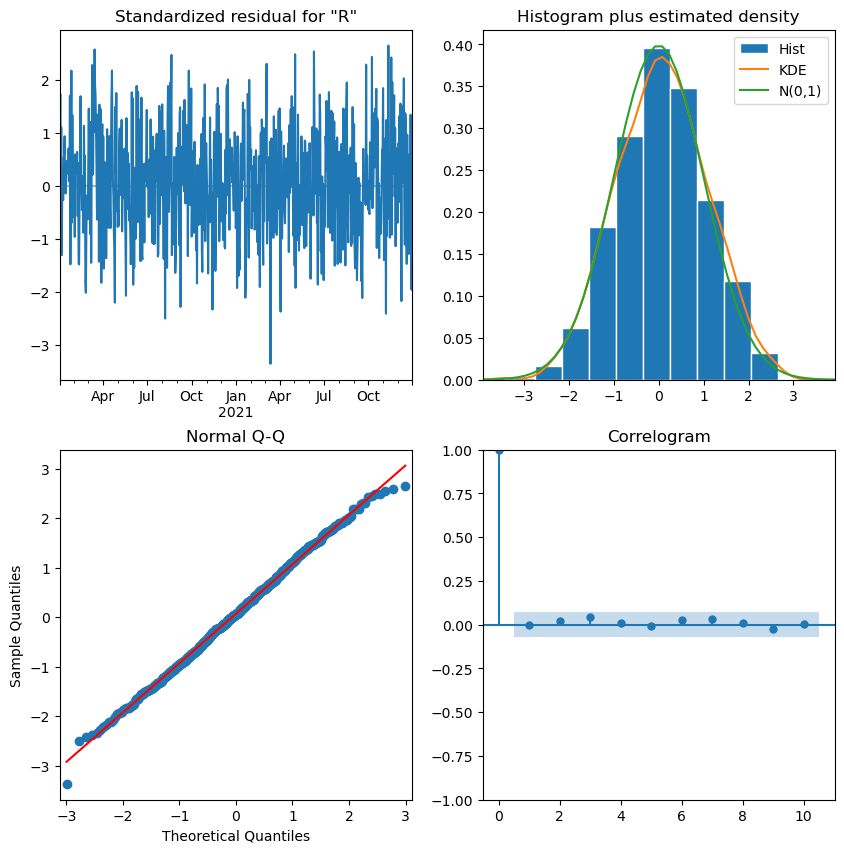

In [150]:
model_fit.plot_diagnostics().show()

- From the calculations above, the model order of (1,1,0) has the lowest AIC of 984 making it the best.  Our guess of model order(2,1,0) from earlier turned out to not be the best choice of model order.  We also tried the 2nd best from the auto_arima(2,1,1) which came close but still wasnt better.  


3.  Perform a forecast using the derived ARIMA model identified in part D2.


In [151]:
test_predictions = model_fit.predict(n_periods=len(test))

In [153]:
mse = mean_squared_error(df['Revenue'], test_predictions)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 0.22399221078176493


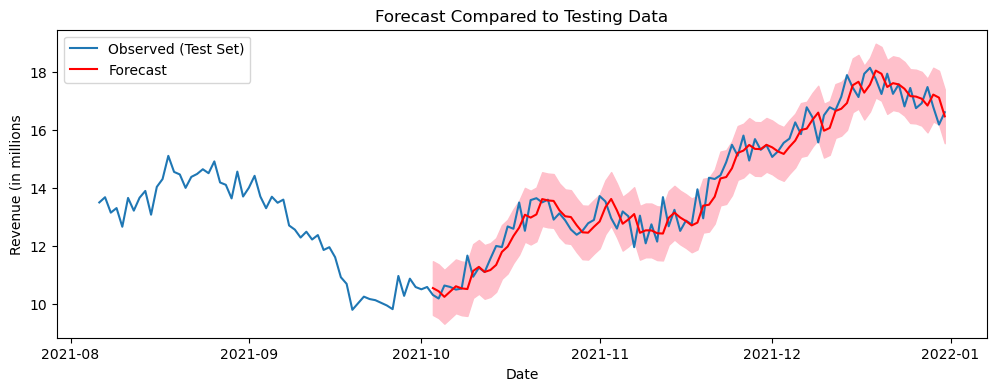

In [154]:
prediction = model_fit.get_prediction(start = -90)
mean_prediction = prediction.predicted_mean
confidence_intervals = prediction.conf_int()
lower_limits = confidence_intervals.loc[:, 'lower Revenue']
upper_limits = confidence_intervals.loc[:, 'upper Revenue']

plt.figure(figsize = (12, 4))
plt.plot(test.index, test, label = 'Observed (Test Set)')
plt.plot(mean_prediction.index, mean_prediction, color = 'r', label = 'Forecast')
plt.fill_between(lower_limits.index, lower_limits, upper_limits, color = 'pink')
plt.title('Forecast Compared to Testing Data')
plt.xlabel('Date')
plt.ylabel('Revenue (in millions')
plt.legend()
plt.show()

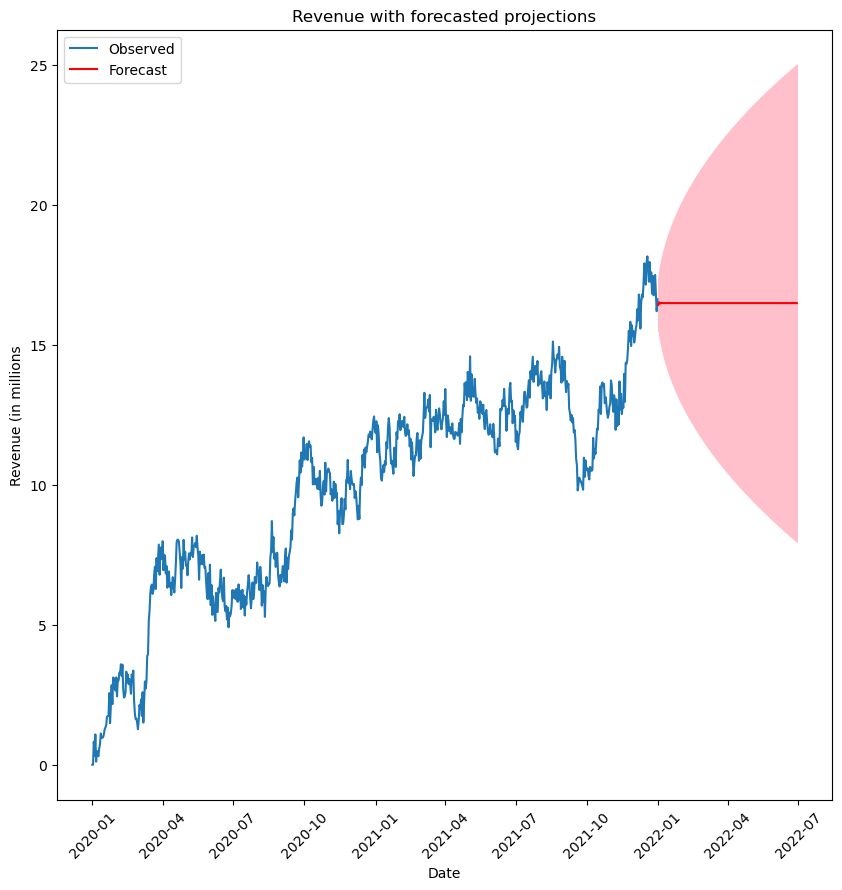

In [ ]:
#forecast with observed
diff_forecast = model_fit.get_forecast(steps = 180)
mean_forecast = diff_forecast.predicted_mean
confidence_intervals = diff_forecast.conf_int()
lower_limits = confidence_intervals.loc[:, 'lower Revenue']
upper_limits = confidence_intervals.loc[:, 'upper Revenue']

plt.plot(df.index, df, label = 'Observed')
plt.plot(mean_forecast.index, mean_forecast, color = 'r', label = 'Forecast')
plt.fill_between(lower_limits.index, lower_limits, upper_limits, color = 'pink')
plt.title('Revenue with forecasted projections')
plt.xlabel('Date')
plt.ylabel('Revenue (in millions')
plt.xticks(rotation = 45)
plt.legend()
plt.show()




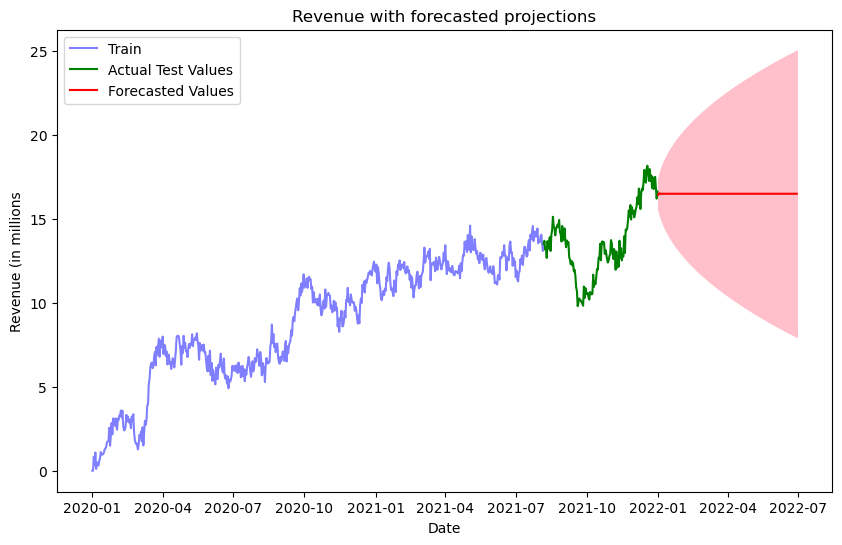

In [ ]:
#forecast with train & test in separate colors
plt.figure(figsize=(10,6))
plt.plot(train.index,train, label='Train', color='blue', alpha=0.5)
plt.plot(test.index, test['Revenue'], label = 'Actual Test Values', color='green')
plt.plot(mean_forecast.index, mean_forecast, label = 'Forecasted Values', color='red')
plt.fill_between(lower_limits.index, lower_limits, upper_limits, color = 'pink')


plt.title('Revenue with forecasted projections')
plt.xlabel('Date')
plt.ylabel('Revenue (in millions')
plt.legend()
plt.show()

### D. continued
4.  Provide the output and calculations of the analysis you performed.
- See above for output and calculations of the analysis in D1,D2 & D3. 

5.  Provide the code used to support the implementation of the time series model.
- See above for code used to support the implementation of the time series model in D1,D2 & D3.



## Part V:  Data Summary and Implications

### E. Summarize your findings and assumptions by doing the following:
1. Discuss the results of your data analysis, including the following points:

- the selection of an ARIMA model
    
    The ARIMA model used had an order of (1,1,0) after using the auto_arima function which returned the best model order.  The AIC for the model order was 984.710.  We then did a manual ARIMA just to confirm and test 2 other orders which did not do better than the order given by the auto_arima function.      

- the prediction interval of the forecast
    
    The observed range is from 2020-01 to 2022-01, as shown in D3.  The prediction interval of the forecast has a range of 6 months, 2022-01 to 2022-07.  This was defined in D3 as 180 steps, which also equals 6 months.        

- a justification of the forecast length
    
    The justification of the forecast length was to keep the testing period at a reasonable length since the dataset is not very large.  The observed range is 24 months, or 2 years so setting the forecast to 6 months seemed logical considering the observed range.  A larger forecast could have made the forecast itself lose value and a shorter forecast length may not have provided enough legnth to be valuable.           

- the model evaluation procedure and error metric

    The model evaluation procedure and error metric used are diagnostic_plots() for model performance is section D2.  The diagnostic_plots() function generates plots about the model performance.  Below are the plots generated from the function.  The top left is a standardized residual for R plot.  The plot does not show any patterns.  The top right plot is a histogram with KDE.  The KDE curve is close to the normal distribution.  The bottom left plot, is a normal q-q plot.  The values along the red line follow a normal distribution.  The bottom right plot is a correlogram.  Any correlations for lag greater than zero are insignificant.

    The error metric was Mean Squared Error as seen below and in the begining of section D3.  With a MSE of .22399221078176493, it would indicate our forecasted values are very close to the observed values.        


In [158]:
#mse 
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 0.22399221078176493


<Figure size 1600x1600 with 0 Axes>

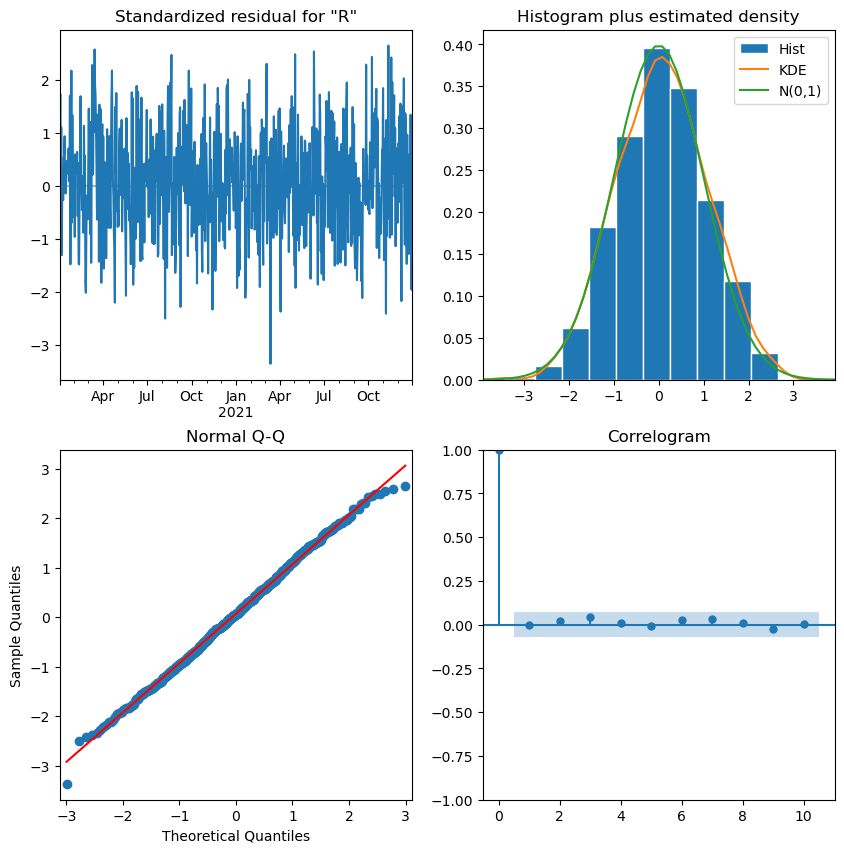

In [160]:
# model performance

plt.figure(figsize = [16,16])
model_fit.plot_diagnostics()
plt.show()


2.  Provide an annotated visualization of the forecast of the final model compared to the test set.

    Below is the final visualization again, that plots both the observed and forecasted data generated by the model with the confidence interval.      


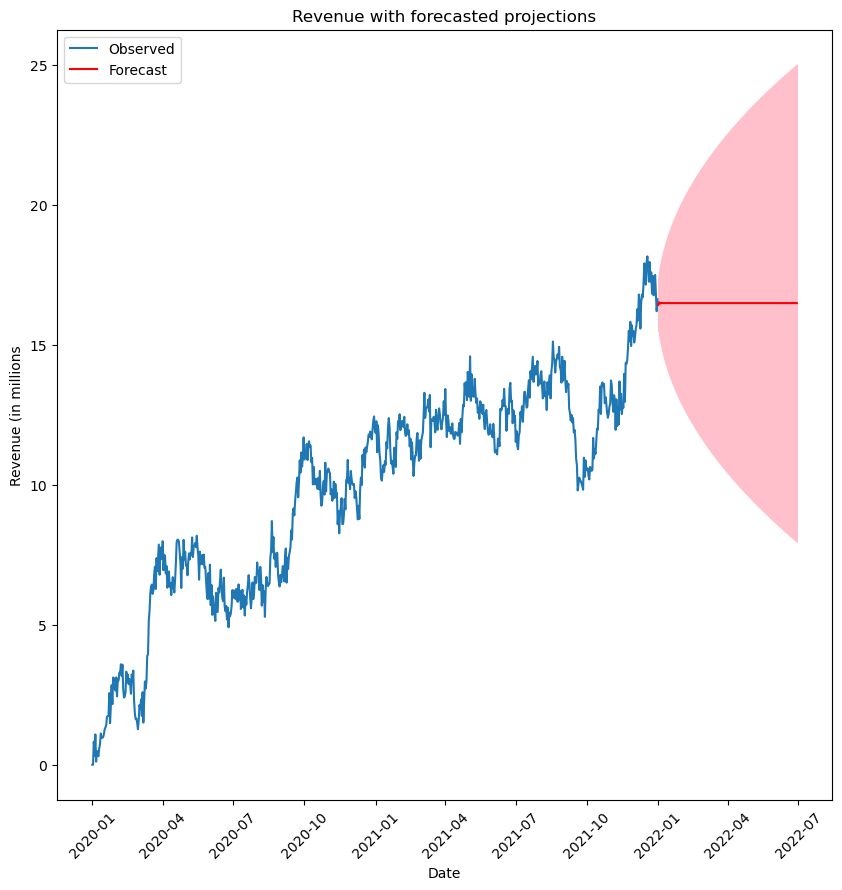

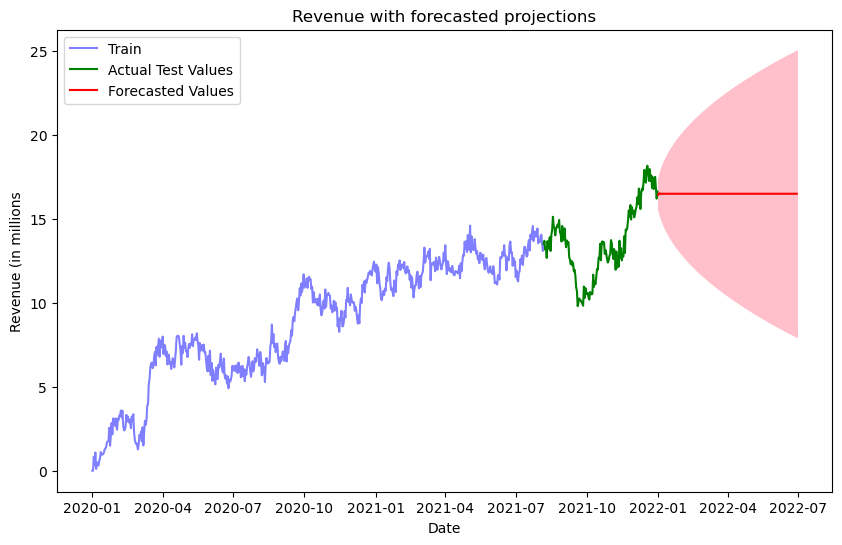

In [161]:
#forecast with observed
diff_forecast = model_fit.get_forecast(steps = 180)
mean_forecast = diff_forecast.predicted_mean
confidence_intervals = diff_forecast.conf_int()
lower_limits = confidence_intervals.loc[:, 'lower Revenue']
upper_limits = confidence_intervals.loc[:, 'upper Revenue']

plt.plot(df.index, df, label = 'Observed')
plt.plot(mean_forecast.index, mean_forecast, color = 'r', label = 'Forecast')
plt.fill_between(lower_limits.index, lower_limits, upper_limits, color = 'pink')
plt.title('Revenue with forecasted projections')
plt.xlabel('Date')
plt.ylabel('Revenue (in millions')
plt.xticks(rotation = 45)
plt.legend()
plt.show()

#forecast with train & test in separate colors
plt.figure(figsize=(10,6))
plt.plot(train.index,train, label='Train', color='blue', alpha=0.5)
plt.plot(test.index, test['Revenue'], label = 'Actual Test Values', color='green')
plt.plot(mean_forecast.index, mean_forecast, label = 'Forecasted Values', color='red')
plt.fill_between(lower_limits.index, lower_limits, upper_limits, color = 'pink')


plt.title('Revenue with forecasted projections')
plt.xlabel('Date')
plt.ylabel('Revenue (in millions')
plt.legend()
plt.show()

The model shows a flat line for forecasted values with a confidence range from around 7 million on the low end to around 25 million on the high end over the next 6 months.  I believe part of the reason for this could be from the dip in the testing data around 2021-10.  Its also possible that 6 months of forecasting is a touch too much for the overall legnth of the observed values.    



3.  Recommend a course of action based on your results.
    
    The recommendation would be to do further analysis on the data.  Starting with a split of 75/25 for the train and test data, as well as cutting down the length of the forecast to 3 months instead of 6.  After doing so, the company could compare the two models to see if the changes made a difference or not.  Continuing the analysis will also benefit from more data being gathered as time goes on, increasing the observed values.  The larger data set may also help with predicting future revenue.     





## Part VI: Reporting

### F.   With the information from part E, create your report using an industry-relevant interactive development environment (e.g., an R Markdown document, a Jupyter Notebook). Include a PDF or HTML document of your executed notebook presentation.

- This notebook has been submitted in both .ipynb and PDF file types.



### G.  List the web sources used to acquire data or segments of third-party code to support the application. Ensure the web sources are reliable.
    None used.

### H.  Acknowledge sources, using in-text citations and references, for content that is quoted, paraphrased, or summarized.
    WGU. (n.d.). Churn Data Consideration and Dictionary. Data Files and Associated Dictionary Files. https://access.wgu.edu/ASP3/aap/content/s8dj4edjf84hd8fcvn3d.zip

    Python | Arima Model for time series forecasting - geeksforgeeks. (2020, February 19). https://www.geeksforgeeks.org/machine-learning/python-arima-model-for-time-series-forecasting/ 

    2.8 autocorrelation | forecasting: Principles and practice (3rd Ed). (n.d.). https://otexts.com/fpp3/acf.html 

    
    